# 08 Model Tuning on Dev-Noisy (Lazy Feature CRNN)

This notebook performs **model tuning** for the lazy-feature CRNN using dev-noisy data.

Tuning targets in this notebook:
- model checkpoint selection (compare multiple CRNN checkpoints)
- decision threshold selection (choose threshold that maximizes dev F1)

No test-noisy data is used for model selection in this notebook.

Important: this CRNN pipeline uses direct sequence input (`[T, 121]`) with **no context stacking**.

### Step 1: Import libraries
This step imports plotting, metrics, tensor, and utility libraries used throughout validation and checkpoint comparison.

In [4]:
import json
import random
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
)

### Step 2: Resolve project paths and runtime config
This step finds the repository root, adds required source modules to Python path, and sets shared configuration for CRNN validation.

In [5]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / 'src').exists() and (candidate / 'data' / 'generated').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root from current working directory.')

ROOT = find_project_root(Path.cwd())
SRC_08 = ROOT / 'src' / '08_crnn'
SRC_07 = ROOT / 'src' / '07_lazy_feature_mlp'
for p in (SRC_08, SRC_07):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from crnn import CRNNVAD
from lazy_dataset import VADLazySequenceDataset

DATA_ROOT = ROOT / 'data' / 'generated'
ARTIFACTS_DIR = ROOT / 'artifacts'
CRNN_CHECKPOINT_DIR = ARTIFACTS_DIR / 'lazy_crnn_checkpoints'

BATCH_SIZE = 8
NUM_WORKERS = 0
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

MANIFEST_TYPE = 'noisy'
NORM_STATS_PATH = DATA_ROOT / 'train' / 'features' / 'noisy_norm_stats.npz'
DEV_SUBSET_FRACTION = None  # Set to e.g. 0.3 for quick checks

CHECKPOINT_FILENAME = 'best_model.pt'
CHECKPOINT_NAME_CONTAINS = 'lazy_crnn'
THRESHOLDS = np.linspace(0.05, 0.95, 19)
TOP_K_PLOTS = 10

print('Project root          :', ROOT)
print('Step 08 src           :', SRC_08)
print('Step 07 src           :', SRC_07)
print('Data root             :', DATA_ROOT)
print('CRNN checkpoint dir   :', CRNN_CHECKPOINT_DIR)
print('Norm stats path       :', NORM_STATS_PATH)
print('Device                :', DEVICE)

Project root          : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL
Step 08 src           : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/src/08_crnn
Step 07 src           : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/src/07_lazy_feature_mlp
Data root             : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/data/generated
CRNN checkpoint dir   : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/lazy_crnn_checkpoints
Norm stats path       : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/data/generated/train/features/noisy_norm_stats.npz
Device                : cuda


### Step 3: Define helper functions
This step defines reusable helpers for checkpoint loading, architecture inference, sequence dataloader construction, and metrics computation.

In [6]:
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_pad_collate_fn():
    def collate(batch):
        lengths = [int(item['num_frames']) for item in batch]
        max_len = max(lengths)
        feat_dim = int(batch[0]['x'].shape[-1])

        x_pad = torch.zeros((len(batch), max_len, feat_dim), dtype=torch.float32)
        y_pad = torch.zeros((len(batch), max_len), dtype=torch.float32)
        mask = torch.zeros((len(batch), max_len), dtype=torch.bool)

        for i, item in enumerate(batch):
            t = int(item['num_frames'])
            x_pad[i, :t] = item['x']
            y_pad[i, :t] = item['y']
            mask[i, :t] = True

        return {'x': x_pad, 'y': y_pad, 'mask': mask}

    return collate


def _extract_state_dict(obj):
    if isinstance(obj, dict):
        if 'state_dict' in obj and isinstance(obj['state_dict'], dict):
            return obj['state_dict']
        if 'model_state_dict' in obj and isinstance(obj['model_state_dict'], dict):
            return obj['model_state_dict']
    return obj


def parse_conv_channels(raw):
    vals = [int(v.strip()) for v in str(raw).split(',') if v.strip()]
    if len(vals) != 2:
        raise ValueError('conv_channels must contain exactly two integers, e.g. "64,128"')
    return tuple(vals)


def load_model_from_checkpoint(checkpoint_path: Path, device: torch.device) -> CRNNVAD:
    raw = torch.load(checkpoint_path, map_location='cpu')
    state = _extract_state_dict(raw)
    if not isinstance(state, dict):
        raise RuntimeError('Checkpoint does not contain a valid state_dict.')

    run_dir = checkpoint_path.parent
    args_path = run_dir / 'train_args.json'

    if args_path.exists():
        args = json.loads(args_path.read_text(encoding='utf-8'))
        conv_channels = parse_conv_channels(args.get('conv_channels', '64,128'))
        conv_kernel_size = int(args.get('conv_kernel_size', 5))
        rnn_hidden_size = int(args.get('rnn_hidden_size', 128))
        rnn_layers = int(args.get('rnn_layers', 1))
        rnn_bidirectional = bool(int(args.get('rnn_bidirectional', 1)))
        dropout = float(args.get('dropout', 0.1))
    else:
        conv_channels = (64, 128)
        conv_kernel_size = 5
        rnn_hidden_size = 128
        rnn_layers = 1
        rnn_bidirectional = True
        dropout = 0.1

    model = CRNNVAD(
        input_dim=121,
        conv_channels=conv_channels,
        conv_kernel_size=conv_kernel_size,
        rnn_hidden_size=rnn_hidden_size,
        rnn_layers=rnn_layers,
        rnn_bidirectional=rnn_bidirectional,
        dropout=dropout,
    )
    model.load_state_dict(state, strict=True)
    model.to(device)
    model.eval()
    return model


def build_lazy_dev_loader():
    dev_dataset = VADLazySequenceDataset(
        generated_dir=DATA_ROOT,
        split='dev',
        manifest_type=MANIFEST_TYPE,
        norm_stats_path=NORM_STATS_PATH if NORM_STATS_PATH.exists() else None,
        subset_fraction=DEV_SUBSET_FRACTION,
        subset_seed=SEED,
    )
    return DataLoader(
        dev_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        drop_last=False,
        collate_fn=make_pad_collate_fn(),
    )


def collect_logits_labels(loader, model, device):
    logits_all = []
    labels_all = []

    with torch.no_grad():
        for batch in loader:
            x = batch['x'].to(device, non_blocking=True)
            y = batch['y'].to(device, non_blocking=True)
            mask = batch['mask'].to(device, non_blocking=True)

            logits = model(x)
            logits_valid = logits[mask].detach().cpu().numpy()
            labels_valid = y[mask].detach().cpu().numpy().astype(np.int64)

            logits_all.append(logits_valid)
            labels_all.append(labels_valid)

    if not logits_all:
        raise RuntimeError('No samples collected from loader.')

    return np.concatenate(logits_all), np.concatenate(labels_all)


def metrics_at_threshold(probs, labels, thr=0.5):
    pred = (probs >= thr).astype(np.int64)
    y = labels.astype(np.int64)

    tp = int(np.sum((pred == 1) & (y == 1)))
    tn = int(np.sum((pred == 0) & (y == 0)))
    fp = int(np.sum((pred == 1) & (y == 0)))
    fn = int(np.sum((pred == 0) & (y == 1)))

    acc = (tp + tn) / max(1, tp + tn + fp + fn)
    prec = tp / max(1, tp + fp)
    rec = tp / max(1, tp + fn)
    f1 = (2.0 * prec * rec) / max(1e-12, (prec + rec))

    far = fp / max(1, fp + tn)
    miss_rate = fn / max(1, fn + tp)

    return {
        'threshold': float(thr),
        'accuracy': float(acc),
        'precision': float(prec),
        'recall': float(rec),
        'f1': float(f1),
        'far': float(far),
        'miss_rate': float(miss_rate),
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
    }

### Step 4: Build dev dataloader and discover CRNN checkpoints
This step builds the dev-noisy lazy sequence dataloader and discovers checkpoint folders under artifacts/lazy_crnn_checkpoints.

In [7]:
SEED = 42
seed_everything(SEED)

loader = build_lazy_dev_loader()

ckpt_candidates = sorted([p for p in CRNN_CHECKPOINT_DIR.rglob(CHECKPOINT_FILENAME) if p.is_file()])
if CHECKPOINT_NAME_CONTAINS:
    key = CHECKPOINT_NAME_CONTAINS.lower()
    ckpt_candidates = [p for p in ckpt_candidates if key in str(p.parent.name).lower()]

print('Dataset size          :', len(loader.dataset))
print('Checkpoint candidates :', len(ckpt_candidates))
for p in ckpt_candidates[:20]:
    print(' -', p.parent.name, '/', p.name)

if not ckpt_candidates:
    raise FileNotFoundError(f'No CRNN checkpoint files found under: {CRNN_CHECKPOINT_DIR}')

Loaded 500 examples from dev noisy manifest
Dataset size          : 500
Checkpoint candidates : 8
 - lazy_crnn_lr0.0003_wd1e-4_dr0.1_seed42 / best_model.pt
 - lazy_crnn_lr0.0003_wd1e-4_dr0.2_seed42 / best_model.pt
 - lazy_crnn_lr0.0003_wd1e-5_dr0.1_seed42 / best_model.pt
 - lazy_crnn_lr0.0003_wd1e-5_dr0.2_seed42 / best_model.pt
 - lazy_crnn_lr0.001_wd1e-4_dr0.1_seed42 / best_model.pt
 - lazy_crnn_lr0.001_wd1e-4_dr0.2_seed42 / best_model.pt
 - lazy_crnn_lr0.001_wd1e-5_dr0.1_seed42 / best_model.pt
 - lazy_crnn_lr0.001_wd1e-5_dr0.2_seed42 / best_model.pt


### Step 5: Evaluate all checkpoints and tune threshold per checkpoint
This step runs inference for each CRNN checkpoint on dev-noisy, performs threshold sweep, and ranks checkpoints by best dev F1.

In [8]:
results = []
failures = []

best_model = None
all_logits = None
all_labels = None
probs = None

for i, ckpt in enumerate(ckpt_candidates, start=1):
    try:
        model = load_model_from_checkpoint(ckpt, DEVICE)
        logits_i, labels_i = collect_logits_labels(loader, model, DEVICE)
        probs_i = 1.0 / (1.0 + np.exp(-logits_i))

        sweep_i = [metrics_at_threshold(probs_i, labels_i, thr=float(t)) for t in THRESHOLDS]
        best_idx = int(np.argmax([m['f1'] for m in sweep_i]))
        best_point = sweep_i[best_idx]

        result = {
            'checkpoint': str(ckpt),
            'checkpoint_name': ckpt.parent.name,
            'best_threshold': best_point['threshold'],
            'accuracy': best_point['accuracy'],
            'precision': best_point['precision'],
            'recall': best_point['recall'],
            'f1': best_point['f1'],
            'far': best_point['far'],
            'miss_rate': best_point['miss_rate'],
            'tp': best_point['tp'],
            'tn': best_point['tn'],
            'fp': best_point['fp'],
            'fn': best_point['fn'],
            'sweep': sweep_i,
        }
        results.append(result)

        if best_model is None or result['f1'] > best_model['f1']:
            best_model = result
            all_logits = logits_i
            all_labels = labels_i
            probs = probs_i

        print(
            f"[{i:02d}/{len(ckpt_candidates)}] OK  {ckpt.parent.name} | "
            f"F1={result['f1']:.6f}, P={result['precision']:.4f}, R={result['recall']:.4f}, "
            f"FAR={result['far']:.4f}, Miss={result['miss_rate']:.4f} @thr={result['best_threshold']:.2f}"
        )
    except Exception as e:
        failures.append((str(ckpt), repr(e)))
        print(f"[{i:02d}/{len(ckpt_candidates)}] FAIL {ckpt.parent.name} | {e}")

if not results:
    raise RuntimeError('No checkpoint evaluated successfully.')

ranked = sorted(results, key=lambda r: r['f1'], reverse=True)
best_model = ranked[0]
best_threshold = float(best_model['best_threshold'])
preds = (probs >= best_threshold).astype(int)

print('\nBest checkpoint:', best_model['checkpoint_name'])
print('Best threshold :', f"{best_threshold:.2f}")
print(
    "Best metrics   : "
    f"F1={best_model['f1']:.6f}, "
    f"Precision={best_model['precision']:.6f}, "
    f"Recall={best_model['recall']:.6f}, "
    f"FAR={best_model['far']:.6f}, "
    f"MissRate={best_model['miss_rate']:.6f}"
)
print('Failures       :', len(failures))

[01/8] OK  lazy_crnn_lr0.0003_wd1e-4_dr0.1_seed42 | F1=0.898949, P=0.8674, R=0.9329, FAR=0.3202, Miss=0.0671 @thr=0.45
[02/8] OK  lazy_crnn_lr0.0003_wd1e-4_dr0.2_seed42 | F1=0.898008, P=0.8680, R=0.9301, FAR=0.3175, Miss=0.0699 @thr=0.50
[03/8] OK  lazy_crnn_lr0.0003_wd1e-5_dr0.1_seed42 | F1=0.898963, P=0.8672, R=0.9331, FAR=0.3208, Miss=0.0669 @thr=0.45
[04/8] OK  lazy_crnn_lr0.0003_wd1e-5_dr0.2_seed42 | F1=0.898008, P=0.8679, R=0.9303, FAR=0.3179, Miss=0.0697 @thr=0.50
[05/8] OK  lazy_crnn_lr0.001_wd1e-4_dr0.1_seed42 | F1=0.911096, P=0.8954, R=0.9273, FAR=0.2431, Miss=0.0727 @thr=0.65
[06/8] OK  lazy_crnn_lr0.001_wd1e-4_dr0.2_seed42 | F1=0.910593, P=0.8876, R=0.9348, FAR=0.2659, Miss=0.0652 @thr=0.60
[07/8] OK  lazy_crnn_lr0.001_wd1e-5_dr0.1_seed42 | F1=0.911299, P=0.8943, R=0.9290, FAR=0.2466, Miss=0.0710 @thr=0.65
[08/8] OK  lazy_crnn_lr0.001_wd1e-5_dr0.2_seed42 | F1=0.910553, P=0.8875, R=0.9349, FAR=0.2662, Miss=0.0651 @thr=0.60

Best checkpoint: lazy_crnn_lr0.001_wd1e-5_dr0.1_see

**Output explanation**

The evaluation on the dev-noisy dataset shows that the best-performing model achieves an F1 score of 0.911 with a learning rate of 0.001, weight decay of 1e-5, and dropout of 0.1, using a threshold of 0.65. Models with the same learning rate consistently outperform those with a lower learning rate, while weight decay and dropout have only minor impact. The results across checkpoints are close, indicating stable and robust training. A threshold around 0.60–0.65 provides a good balance between precision and recall, reducing false alarms while maintaining a low miss rate.

### Step 6: Print checkpoint leaderboard
This step prints a ranked table of all successfully evaluated CRNN checkpoints.

In [9]:
print('Top checkpoints by dev F1:')
print('-' * 132)
print(f"{'rank':>4s}  {'checkpoint':<55s}  {'thr':>5s}  {'f1':>9s}  {'acc':>9s}  {'prec':>9s}  {'rec':>9s}  {'far':>9s}  {'miss':>9s}")
print('-' * 132)

for idx, r in enumerate(ranked, start=1):
    print(
        f"{idx:>4d}  {r['checkpoint_name']:<55.55s}  {r['best_threshold']:>5.2f}  "
        f"{r['f1']:>9.6f}  {r['accuracy']:>9.6f}  {r['precision']:>9.6f}  {r['recall']:>9.6f}  "
        f"{r['far']:>9.6f}  {r['miss_rate']:>9.6f}"
    )

if failures:
    print('\nFailed checkpoints:')
    for ckpt, err in failures:
        print(' -', Path(ckpt).parent.name, '|', err)

Top checkpoints by dev F1:
------------------------------------------------------------------------------------------------------------------------------------
rank  checkpoint                                                 thr         f1        acc       prec        rec        far       miss
------------------------------------------------------------------------------------------------------------------------------------
   1  lazy_crnn_lr0.001_wd1e-5_dr0.1_seed42                     0.65   0.911299   0.874880   0.894289   0.928968   0.246572   0.071032
   2  lazy_crnn_lr0.001_wd1e-4_dr0.1_seed42                     0.65   0.911096   0.874791   0.895446   0.927303   0.243122   0.072697
   3  lazy_crnn_lr0.001_wd1e-4_dr0.2_seed42                     0.60   0.910593   0.872990   0.887586   0.934824   0.265854   0.065176
   4  lazy_crnn_lr0.001_wd1e-5_dr0.2_seed42                     0.60   0.910553   0.872921   0.887462   0.934879   0.266200   0.065121
   5  lazy_crnn_lr0.0003_wd1e-5_

**Output explanation**

The evaluation on the dev-noisy dataset shows that the best-performing model achieves an F1 score of 0.911 with a learning rate of 0.001, weight decay of 1e-5, and dropout of 0.1, using a threshold of 0.65. Models with a higher learning rate (0.001) consistently outperform those with a lower learning rate (0.0003), while weight decay and dropout have only minor effects on performance. The results across checkpoints are very close, indicating stable and robust training. A threshold around 0.60–0.65 provides a good balance between precision and recall, reducing the false alarm rate while maintaining a low miss rate.

### Step 7: Compare metrics across top checkpoints
This step visualizes accuracy, precision, recall, F1, FAR, and miss rate across top CRNN checkpoints.

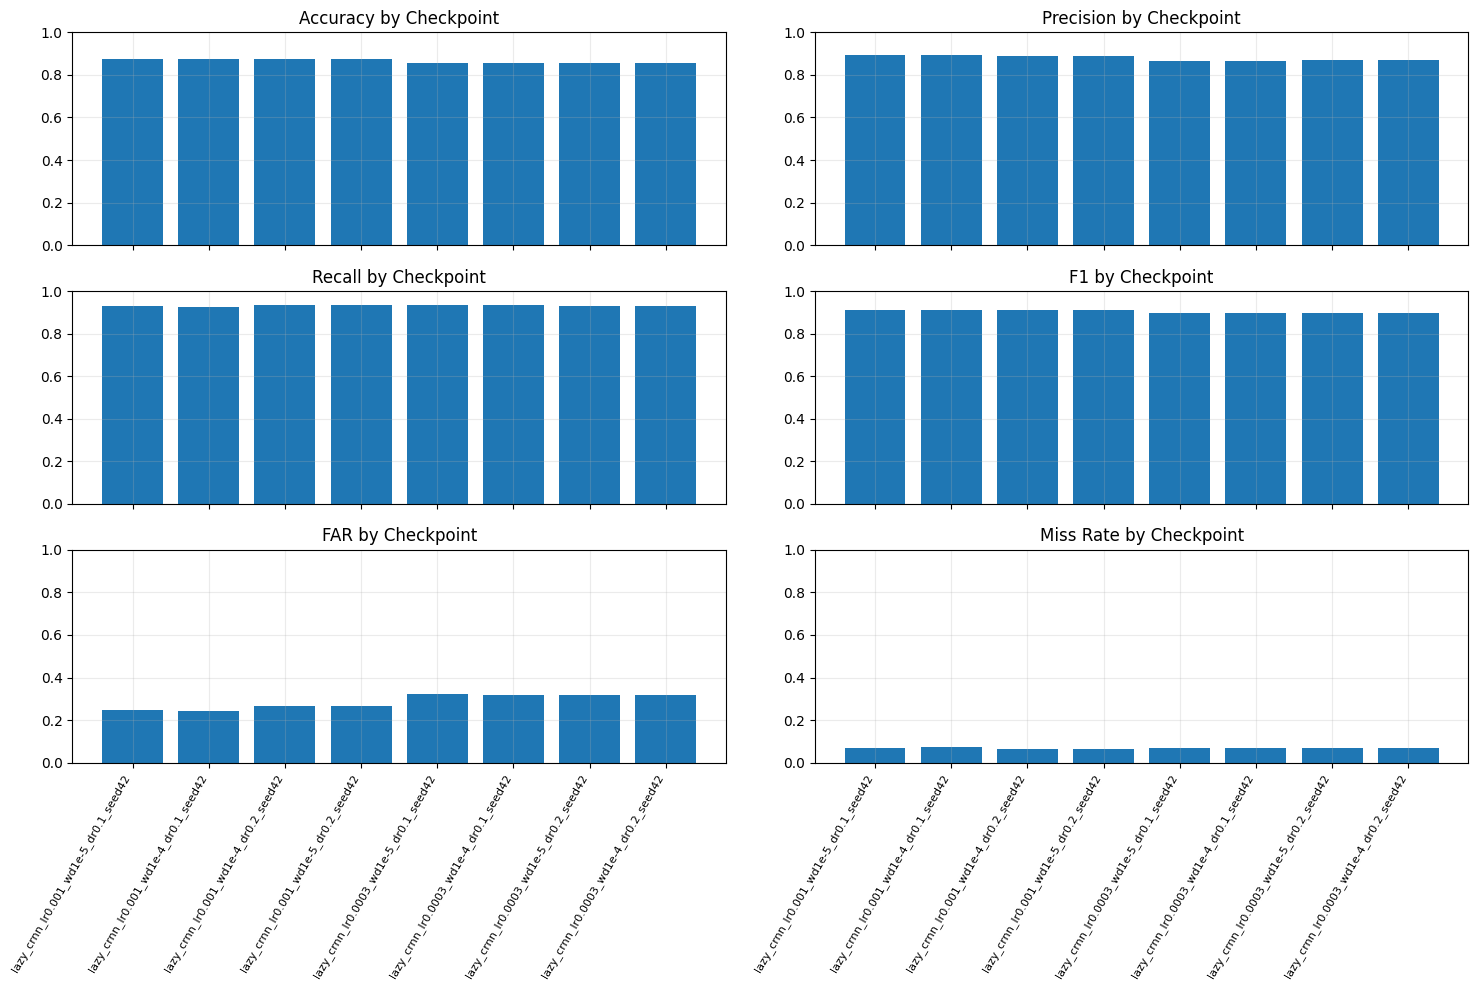

Best checkpoint: lazy_crnn_lr0.001_wd1e-5_dr0.1_seed42
Best threshold : 0.65
Best metrics   : acc=0.874880,  prec=0.894289,  rec=0.928968,  f1=0.911299,  far=0.246572,  miss=0.071032


In [10]:
top = ranked[: min(TOP_K_PLOTS, len(ranked))]
names = [r['checkpoint_name'] for r in top]
x = np.arange(len(top))

acc_vals = [r['accuracy'] for r in top]
prec_vals = [r['precision'] for r in top]
rec_vals = [r['recall'] for r in top]
f1_vals = [r['f1'] for r in top]
far_vals = [r['far'] for r in top]
miss_vals = [r['miss_rate'] for r in top]

fig, axes = plt.subplots(3, 2, figsize=(15, 10), sharex=True)
axes = axes.ravel()

axes[0].bar(x, acc_vals)
axes[0].set_title('Accuracy by Checkpoint')
axes[0].set_ylim(0, 1)

axes[1].bar(x, prec_vals)
axes[1].set_title('Precision by Checkpoint')
axes[1].set_ylim(0, 1)

axes[2].bar(x, rec_vals)
axes[2].set_title('Recall by Checkpoint')
axes[2].set_ylim(0, 1)

axes[3].bar(x, f1_vals)
axes[3].set_title('F1 by Checkpoint')
axes[3].set_ylim(0, 1)

axes[4].bar(x, far_vals)
axes[4].set_title('FAR by Checkpoint')
axes[4].set_ylim(0, 1)

axes[5].bar(x, miss_vals)
axes[5].set_title('Miss Rate by Checkpoint')
axes[5].set_ylim(0, 1)

for ax in axes:
    ax.grid(alpha=0.25)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=60, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

print('Best checkpoint:', best_model['checkpoint_name'])
print('Best threshold :', f"{best_threshold:.2f}")
print('Best metrics   :',
      f"acc={best_model['accuracy']:.6f}, ",
      f"prec={best_model['precision']:.6f}, ",
      f"rec={best_model['recall']:.6f}, ",
      f"f1={best_model['f1']:.6f}, ",
      f"far={best_model['far']:.6f}, ",
      f"miss={best_model['miss_rate']:.6f}")

**Output explanation**

The plots show that performance across all checkpoints is very consistent. Accuracy, precision, recall, and F1 scores are all high and vary only slightly between models, indicating stable training and low sensitivity to hyperparameters. Models with learning rate 0.001 generally achieve better F1 and lower FAR compared to those with 0.0003. FAR is noticeably higher for lower learning rate models, while miss rate remains low and similar across all runs. Overall, the results confirm that the model is robust, with small performance differences between configurations, and achieves a good balance between detection accuracy and error rates.

### Step 8: Visualize confusion matrix for best checkpoint
This step plots the confusion matrix of the selected best CRNN checkpoint using its tuned decision threshold.

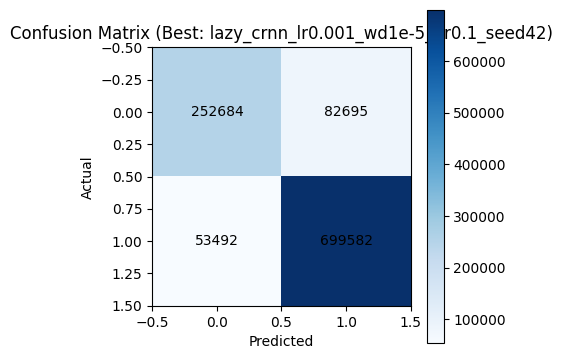

In [11]:
cm = confusion_matrix(all_labels, preds)

plt.figure(figsize=(4.5, 4.0))
plt.imshow(cm, cmap='Blues')
plt.title(f"Confusion Matrix (Best: {best_model['checkpoint_name']})")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

**Output explanation**

The confusion matrix shows that the model correctly classifies most samples, with a large number of true positives (699,582) and true negatives (252,684). There are relatively fewer false positives (82,695) and false negatives (53,492).
This indicates that the model is strong at detecting speech (high true positives) while maintaining a reasonable number of false alarms. The lower number of false negatives also aligns with the high recall, meaning the model rarely misses actual speech segments. Overall, the model achieves a good balance between detection accuracy and error rates.

### Step 9: Plot ROC curve for best checkpoint
This step computes and visualizes ROC and AUC for the selected best CRNN checkpoint on dev-noisy.

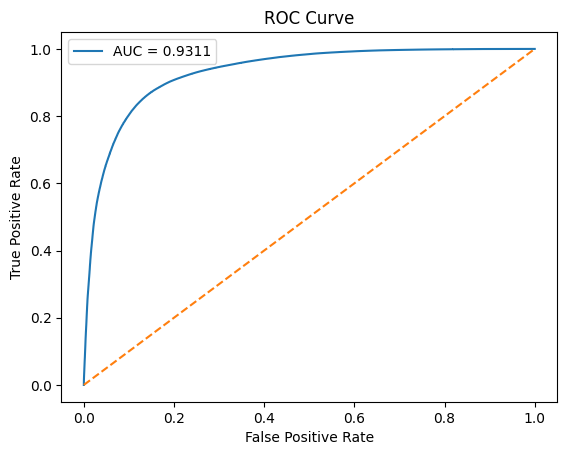

In [12]:
fpr, tpr, _ = roc_curve(all_labels, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

**Output explanation**

The ROC curve shows that the model performs well across different thresholds, with the curve staying far above the diagonal baseline. The AUC score of 0.9311 indicates strong overall classification performance. This means the model can effectively distinguish between speech and non-speech, achieving high true positive rates while keeping false positive rates relatively low.

### Step 10: Plot precision-recall curve for best checkpoint
This step visualizes the precision-recall trade-off for the selected best CRNN checkpoint.

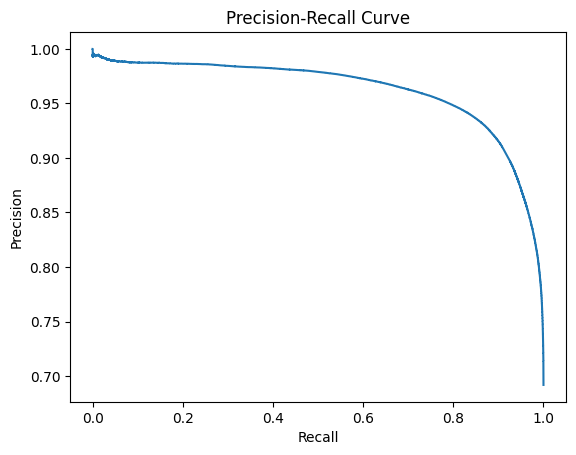

In [13]:
precision_vals, recall_vals, _ = precision_recall_curve(all_labels, probs)

plt.figure()
plt.plot(recall_vals, precision_vals)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

**Output explanation**

The Precision-Recall curve shows that the model maintains high precision across a wide range of recall values. Precision remains close to 1.0 at lower recall levels and gradually decreases as recall increases. This indicates that the model performs well in detecting speech while keeping false positives low. The smooth decline also suggests a good trade-off between precision and recall, confirming strong overall performance on the task.

### Step 11: Visualize F1 versus threshold
This step plots the F1-threshold curve for the best checkpoint to inspect threshold behavior.

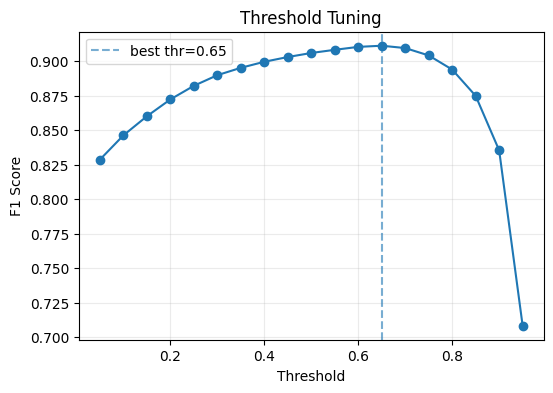

Best threshold from curve: 0.65
Best F1 from curve       : 0.911299


In [14]:
thresholds = THRESHOLDS
f1_scores = []

for t in thresholds:
    preds_t = (probs >= t).astype(np.int64)
    f1_scores.append(f1_score(all_labels, preds_t))

best_idx = int(np.argmax(f1_scores))
best_thr_curve = float(thresholds[best_idx])
best_f1_curve = float(f1_scores[best_idx])

plt.figure(figsize=(6, 4))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_thr_curve, linestyle='--', alpha=0.6, label=f'best thr={best_thr_curve:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Threshold Tuning')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print(f"Best threshold from curve: {best_thr_curve:.2f}")
print(f"Best F1 from curve       : {best_f1_curve:.6f}")

**Output explanation**

The threshold tuning curve shows how F1 score changes with different decision thresholds. The F1 score increases as the threshold rises and reaches its peak around 0.65, then starts to decline.

This indicates that a threshold of 0.65 provides the best balance between precision and recall. Lower thresholds lead to more false positives, while higher thresholds reduce recall, resulting in lower overall performance.

### Step 12: Export evaluation artifacts and tuned configuration
This step saves prediction arrays, checkpoint leaderboard, and final tuned config for downstream use.

In [15]:
eval_dir = ARTIFACTS_DIR / 'eval_outputs_lazy_crnn'
eval_dir.mkdir(parents=True, exist_ok=True)

np.save(eval_dir / 'eval_logits.npy', all_logits)
np.save(eval_dir / 'eval_probs.npy', probs)
np.save(eval_dir / 'eval_labels.npy', all_labels)

with open(eval_dir / 'checkpoint_leaderboard.json', 'w', encoding='utf-8') as f:
    json.dump(
        [
            {
                'checkpoint': r['checkpoint'],
                'checkpoint_name': r['checkpoint_name'],
                'best_threshold': r['best_threshold'],
                'accuracy': r['accuracy'],
                'precision': r['precision'],
                'recall': r['recall'],
                'f1': r['f1'],
                'far': r['far'],
                'miss_rate': r['miss_rate'],
                'tp': r['tp'],
                'tn': r['tn'],
                'fp': r['fp'],
                'fn': r['fn'],
            }
            for r in ranked
        ],
        f,
        indent=2,
    )

crnn_config_path = ARTIFACTS_DIR / 'final_tuned_config_lazy_crnn.json'
with open(crnn_config_path, 'w', encoding='utf-8') as f:
    json.dump(
        {
            'checkpoint': best_model['checkpoint'],
            'threshold': best_threshold,
            'dev_metrics': {
                'accuracy': best_model['accuracy'],
                'precision': best_model['precision'],
                'recall': best_model['recall'],
                'f1': best_model['f1'],
                'far': best_model['far'],
                'miss_rate': best_model['miss_rate'],
                'tp': best_model['tp'],
                'tn': best_model['tn'],
                'fp': best_model['fp'],
                'fn': best_model['fn'],
            },
        },
        f,
        indent=2,
    )

print('Saved evaluation arrays to:', eval_dir)
print('Saved leaderboard to     :', eval_dir / 'checkpoint_leaderboard.json')
print('Saved tuned config to    :', crnn_config_path)

Saved evaluation arrays to: /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/eval_outputs_lazy_crnn
Saved leaderboard to     : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/eval_outputs_lazy_crnn/checkpoint_leaderboard.json
Saved tuned config to    : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/final_tuned_config_lazy_crnn.json
